### Önemli Noktalar:

Polars, CSV ve Parquet gibi birçok veri formatını okuma/yazma konusunda destek vermektedir.

İfadeler, modüler DataFrame dönüşümlerine olanak tanır.

Filtreleme, seçme, gruplandırma, birleştirme ve bir araya getirme işlemleri, karmaşık iş akışları oluşturmak için bir araya gelir.

### Düşünme Soruları:

Polars hangi dosya formatlarını okuma ve yazma konusunda destekliyor?

Veri çerçevelerini birleştirmek için JOIN yerine CONCAT'ı ne zaman kullanabilirsiniz?

İfadeler, karmaşık bir DataFrame işlem hattını modüler bir şekilde nasıl oluşturabilir?

Filtrelenmiş veya birleştirilmiş veriler ne gibi şekillerde bilgi sağlayabilir?

Polars, büyük veri kümeleriyle çalışırken Pandas'a kıyasla nasıl bir performans sergiler?

### Zorluklar:

JSON verilerini okuyun ve Parquet formatına yazın.

İki veri setini birleştirin ve ardından group_by toplama işlemini gerçekleştirin.

Sütunların bir alt kümesini seçin, satırları filtreleyin ve yeni bir sütun ekleyin.

Sütunlar arasındaki ilişkileri bulmak için bir ifade oluşturun.

Pandas'ın yeteneklerini aşan analizler için Polars kullanın.

In [1]:
!pip install polars

In [3]:
import polars as pl

# Create DataFrame 
data = [{"fruit": "apple", "count": 10, "price": 0.50}, 
        {"fruit": "banana", "count": 20, "price": 0.25}]
df = pl.from_dicts(data)

# Expressions to select, filter, aggregate
sel = df.select(["fruit", "count"]) # Select columns
filt = sel.filter(pl.col("fruit") == "apple") # Filter rows
agg = filt.group_by("fruit").agg(pl.col("count").sum()) # Aggregate

print(agg)

shape: (1, 2)
┌───────┬───────┐
│ fruit ┆ count │
│ ---   ┆ ---   │
│ str   ┆ i64   │
╞═══════╪═══════╡
│ apple ┆ 10    │
└───────┴───────┘


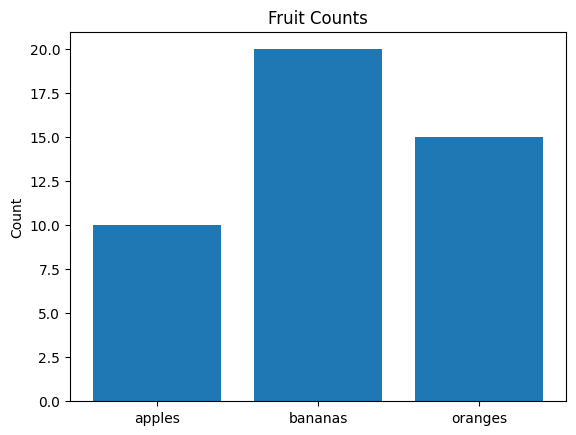

In [4]:
import polars as pl
import matplotlib.pyplot as plt

# Create sample data
data = [{"fruit": "apples", "count": 10}, 
        {"fruit": "bananas", "count": 20},
        {"fruit": "oranges", "count": 15}]  
df = pl.from_dicts(data)

# Extract columns 
fruits = df['fruit']
counts = df['count']

# Plot bar chart
fig, ax = plt.subplots()
ax.bar(fruits, counts)
ax.set_ylabel('Count')
ax.set_title('Fruit Counts')
plt.show()

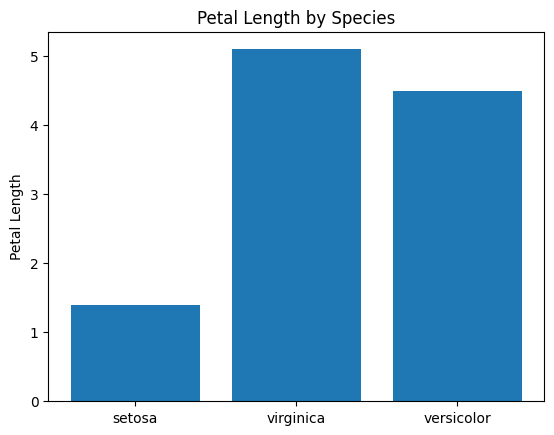

In [7]:
import polars as pl
import matplotlib.pyplot as plt

data = [{"species": "setosa", "petal_length": 1.4}, 
        {"species": "virginica", "petal_length": 5.1},
        {"species": "versicolor", "petal_length": 4.5}]
        
df2 = pl.from_dicts(data)

# Extract columns
species = df2['species']
lengths = df2['petal_length']

# Plot bar chart
fig, ax = plt.subplots()
ax.bar(species, lengths)
ax.set_ylabel('Petal Length') 
ax.set_title("Petal Length by Species")
plt.show()

In [8]:
# Join DataFrames
joined = df.join(df2, on=["fruit_name"]) 

# Visualize
joined.plot.scatter(x="count", y="price")

ColumnNotFoundError: unable to find column "fruit_name"; valid columns: ["species", "petal_length"]

## Ders Üzerine Düşünceler
### Özet

Bu derste, paralel hesaplama sistemlerinde tablo verileriyle çalışmak için Pandas DataFrame'lerine alternatifleri inceledik. Temel kazanımlar şunlardı:

### Önemli Noktalar

Pandas, vektörleştirme yoluyla hız sağlayan Numpy ndarray'leri üzerine inşa edilmiştir.

PySpark, büyük veri kümeleri için ideal olan dağıtılmış, paralel işlemeyi kümeler üzerinde mümkün kılar.

Dask, tek bir makinede bellek kapasitesinin ötesinde işlem gücü sağlamaya olanak tanır.

Polars, DataFrame'ler için yeni ortaya çıkan bir standarttır.

### Düşünme Soruları

Pandas ile çalışırken karşılaştığınız bazı sınırlamalar nelerdir? Alternatif bir çözüm ne zaman daha uygun olabilir?

PySpark veya Dask, Pandas'ın tek başına mümkün olmayan daha büyük veri kümeleriyle çalışmanıza nasıl yardımcı olabilir?

PySpark veya Dask'ı etkili bir şekilde kullanmak için hangi altyapı ve yapılandırma gereklidir?

Pandas'ın kullanım kolaylığı ile PySpark/Dask'ın ölçeklenebilirliği arasındaki avantaj ve dezavantajlar nelerdir?

Bu üç aracı daha büyük bir projede birlikte nasıl kullanabilirsiniz?

### Zorluklar

1 GB'lık bir CSV dosyasını Pandas'a yükleyin. Performansı Dask ile nasıl karşılaştırılır?

PySpark'ı yerel olarak kurun ve 1 milyon satırlık veriyi okuma performansını Pandas ile karşılaştırın.

Dask veri alımından gelen çıktıları PySpark makine öğrenimi işlem hattına entegre edin.

Pandas kullanarak PySpark kümesinden rastgele örnek çıktılarını analiz edin.

Dağıtılmış uygulama: PySpark'ta 100 milyon satırın ortalamasını hesaplayın, Pandas'a çıktı verin.

### Kod Örnekleri

İşte rastgele meyve fiyatlarıyla büyük bir Pandas DataFrame oluşturmak ve meyve türüne göre bölümlendirilmiş fiyatlar üzerinde istatistikler hesaplamak için kullanılan kod:

In [9]:
import pandas as pd
import numpy as np

# Create small dummy DataFrame
np.random.seed(1)
fruits = ['apple', 'banana', 'strawberry', 'kiwi']  
N = 1000
df = pd.DataFrame({
   'fruit': np.random.choice(fruits, N),
   'price': np.random.uniform(1, 10, N)   
})

# Function to process DataFrame
def get_prices_by_fruit(df):
    return df.groupby('fruit')['price'].agg(['count', 'mean', 'min', 'max'])

prices = get_prices_by_fruit(df) 
print(prices)

            count      mean       min       max
fruit                                          
apple         265  5.610179  1.047159  9.986685
banana        241  5.625379  1.071396  9.934308
kiwi          237  5.420487  1.006879  9.941144
strawberry    257  5.358464  1.028016  9.922119


In [11]:
data = { 'cows': [ 'Aberdeen', 'Brangus'],
         'pigs': [ 'Mangalica', 'Tamworth']}

df = pd.DataFrame(data)
df


,cows,pigs
0,Aberdeen,Mangalica
1,Brangus,Tamworth
